# CMIR Evaluation — Fold-Factor Sweep

Interactive view of `IR/evaluation_results.json` produced by `IR/evaluate.py`. Each section
renders one of the charts from `IR/plot.py` together with the insight it surfaces.

**Setup:** the kernel only needs `matplotlib`, `numpy`, and `pandas` — no Keras / da4ml.
If the JSON is stale, regenerate it with `KERAS_BACKEND=jax python IR/evaluate.py` from the
repo root.

In [3]:
%matplotlib inline
import sys
from pathlib import Path

# Locate IR/ regardless of whether this notebook was opened from the repo root
# or from notebooks/.
HERE = Path.cwd()
for candidate in [HERE, HERE.parent, HERE.parent.parent]:
    if (candidate / 'IR' / 'plot.py').exists():
        REPO = candidate
        break
else:
    raise RuntimeError('Could not find IR/plot.py — run from inside the CMIR repo.')

sys.path.insert(0, str(REPO / 'IR'))

import plot

RESULTS_PATH = REPO / 'IR' / 'evaluation_results.json'
results = plot.load_results(RESULTS_PATH)
print(f'Loaded {len(results)} fold factors: K ∈ {sorted(results.keys())}')
print(f'Source: {RESULTS_PATH}')

Loaded 4 fold factors: K ∈ [1, 2, 4, 8]
Source: /Users/sriharshavitta/Projects/CMIR/IR/evaluation_results.json


## Headline summary

Key numbers at a glance — area, latency, throughput, and the normalised
area-latency product (ALP) for each fold factor.

In [4]:
import pandas as pd

rows = []
for K in sorted(results.keys()):
    m = results[K]
    rows.append({
        'K': K,
        'LUTs': m['total_luts'],
        'FFs': m['total_ffs'],
        'Makespan (cyc)': m['makespan'],
        'Latency (ns)': round(m['makespan_ns'], 1) if m.get('makespan_ns') else None,
        'II': m['II'],
        'Throughput (MHz)': m.get('throughput_mhz'),
        'Batches in flight': m.get('batches_in_flight'),
        'ALP (norm)': round(m.get('alp_normalised', 1.0), 3),
        'Area reduction': f"{m.get('area_reduction_ratio', 1.0):.2f}×",
    })
df = pd.DataFrame(rows).set_index('K')
df

,LUTs,FFs,Makespan (cyc),Latency (ns),II,Throughput (MHz),Batches in flight,ALP (norm),Area reduction
K,,,,,,,,,
1,129316,84732,24,80.0,1,300.0,24,1.000,1.00×
2,9277,22784,53,176.7,2,150.0,27,0.158,13.94×
4,7501,27648,55,183.3,4,75.0,14,0.133,17.24×
8,6677,40832,61,203.3,8,37.5,8,0.131,19.37×


## 1. Pareto frontier — the headline trade-off

Every K=1, 2, 4, 8 design lies on the Pareto frontier: each step trades area
for latency monotonically. K=1 (fully unfolded) is fastest but ~13× larger
than K=2; K=8 is smallest but slowest. Choose K based on which constraint
is binding — area budget or latency target.

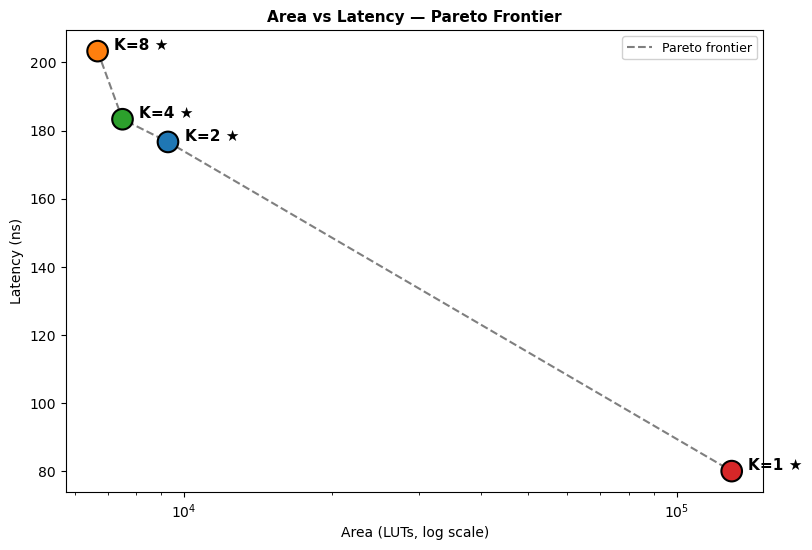

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 6))
plot.plot_pareto(results, ax)
plt.show()

## 2. Area-latency product — folding's headline win

ALP is the single-number summary: smaller area × smaller latency = lower ALP.
K=4 and K=8 hit ~13% of the K=1 ALP — folding wins by a wide margin even
with the latency tax.

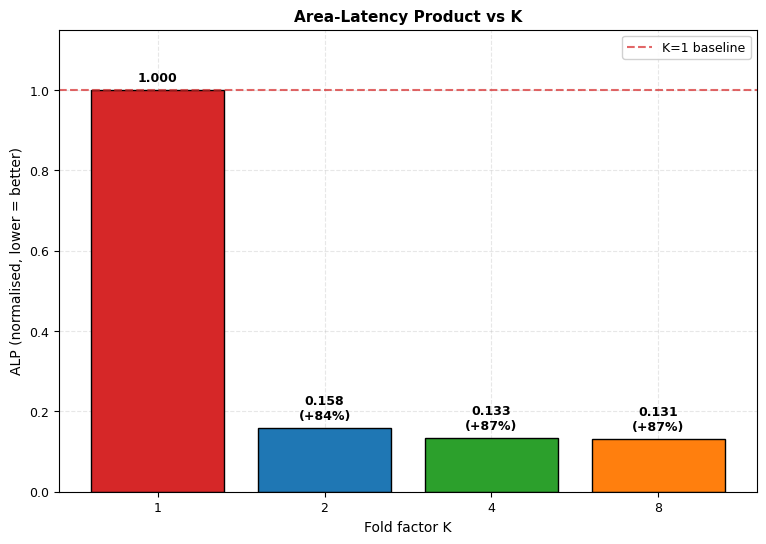

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
plot.plot_alp_comparison(results, ax)
plt.show()

## 3. Resource & latency scaling

LUTs (left axis, log) drop super-linearly with K while latency (right axis)
grows sub-linearly. That asymmetry is exactly why ALP improves: the area
savings outpace the latency cost.

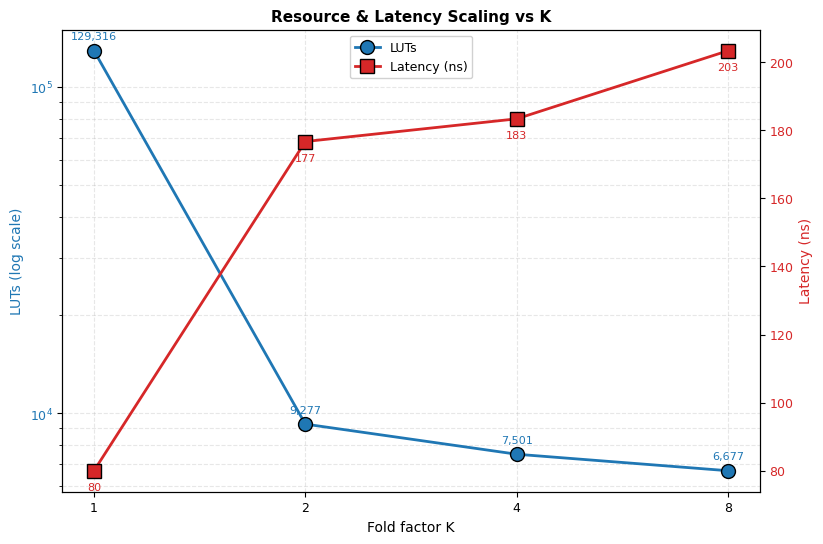

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
plot.plot_resource_scaling(results, ax)
plt.show()

## 4. Throughput vs area efficiency

Throughput drops 1/K (II = K → fmax / K), but inferences per LUT per second
(area efficiency) peaks at the smallest K that still passes timing. The peak
tells you which design extracts the most work per LUT.

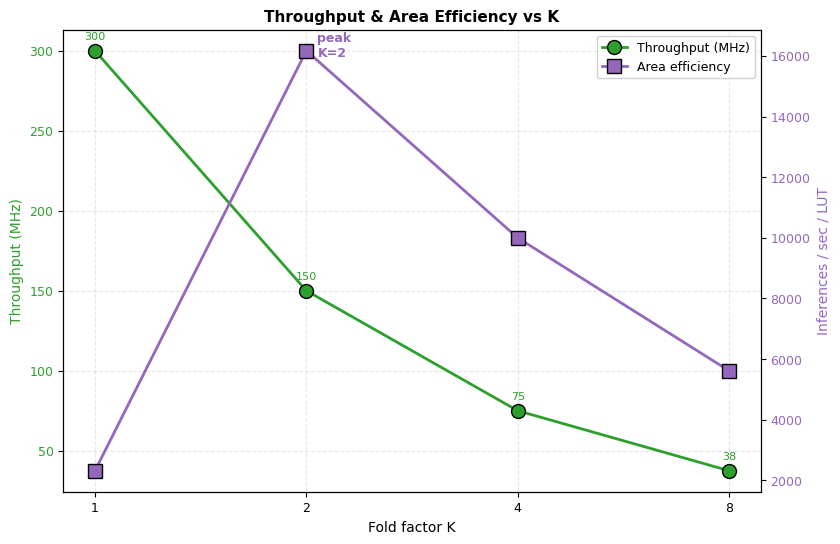

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
plot.plot_throughput_efficiency(results, ax)
plt.show()

## 5. Where do the LUTs go? (composition)

Once folded, the per-op rollup adds up to the total LUT count and dense
layers dominate (~80%). For K=1 the headline number is da4ml's
end-to-end ground truth — most of that cost is cross-layer pipeline
logic the per-op rollup can't see, so it's bucketed as **unattributed**.
That grey K=1 bar is the methodology gap, not a real op.

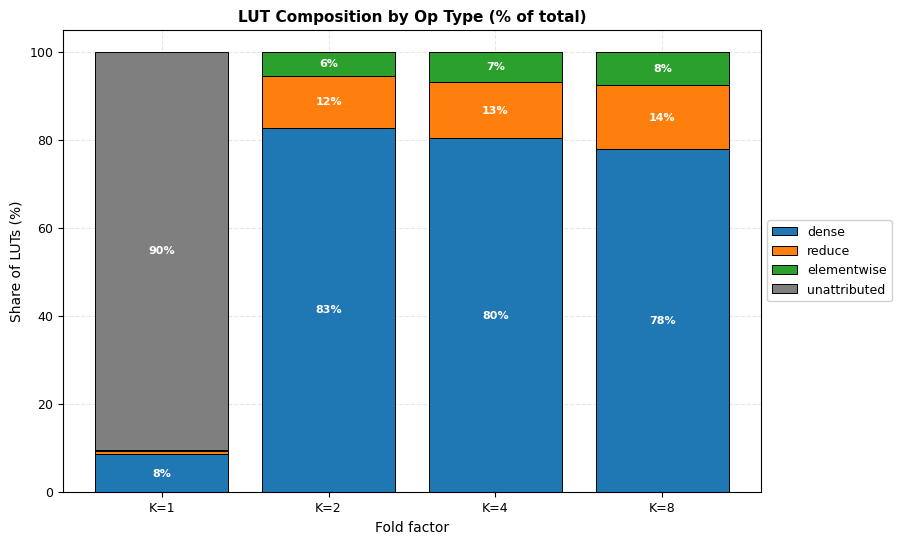

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
plot.plot_lut_composition(results, ax, percent=True)
plt.show()

## 6. The cost of folding — buffer flip-flops

Folding moves cost from LUTs to FFs: the longer schedules require buffers to
hold inter-stage operands across the II window. Buffer FFs (red) grow ~2×
from K=2 → K=8, and dwarf compute FFs (blue, barely visible). For K=1 the
hatched grey block represents da4ml's pipeline registers folded into the
fully unrolled dataflow.

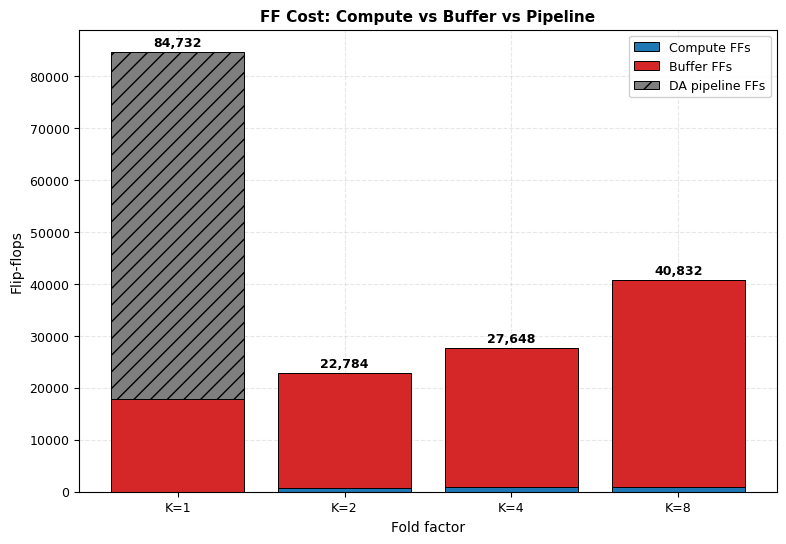

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
plot.plot_ff_growth(results, ax)
plt.show()

## 7. Schedule quality — slack and compactness

Critical-path utilisation = pipeline_depth / makespan. It drops as K grows
because folded schedules add idle slots inside the II window. Schedule
compactness is the average occupancy across all compute vertices —
consistently low here because most vertices spend most of their II idle
(II = 1..8 cycles, but each vertex only fires once per II).

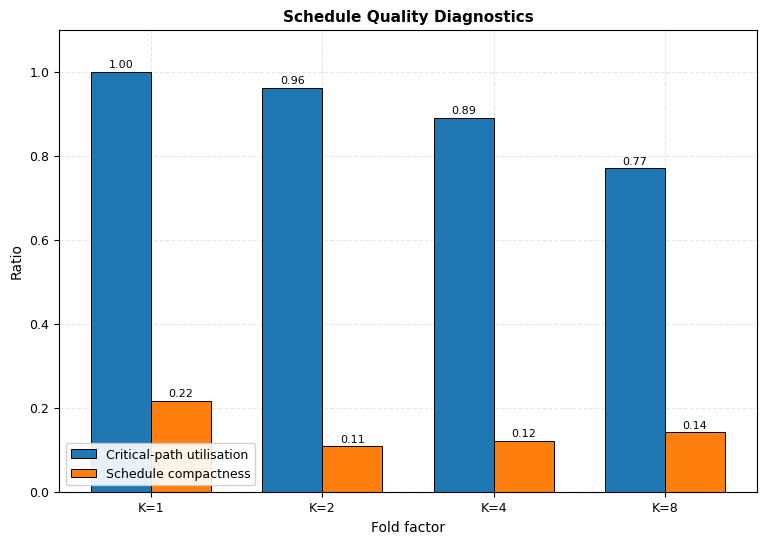

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
plot.plot_schedule_quality(results, ax)
plt.show()

## 8. Op-type cost heatmap

Per-op LUT cost across K (log-scale colour). Dense layers are the dominant
cost everywhere; reduce and elementwise stay roughly flat — they don't
benefit from folding because they're already cheap.

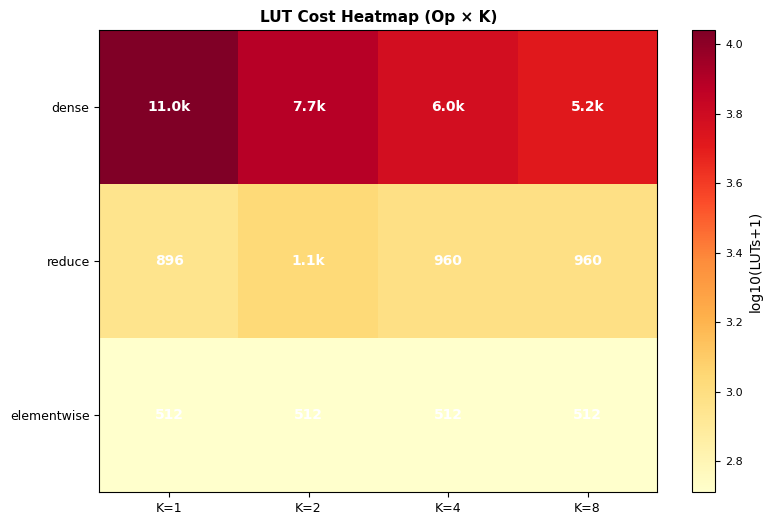

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
plot.plot_op_heatmap(results, ax)
plt.show()

## 9. All-in-one dashboard

All eight charts on one figure — useful for paper figures or quick review.

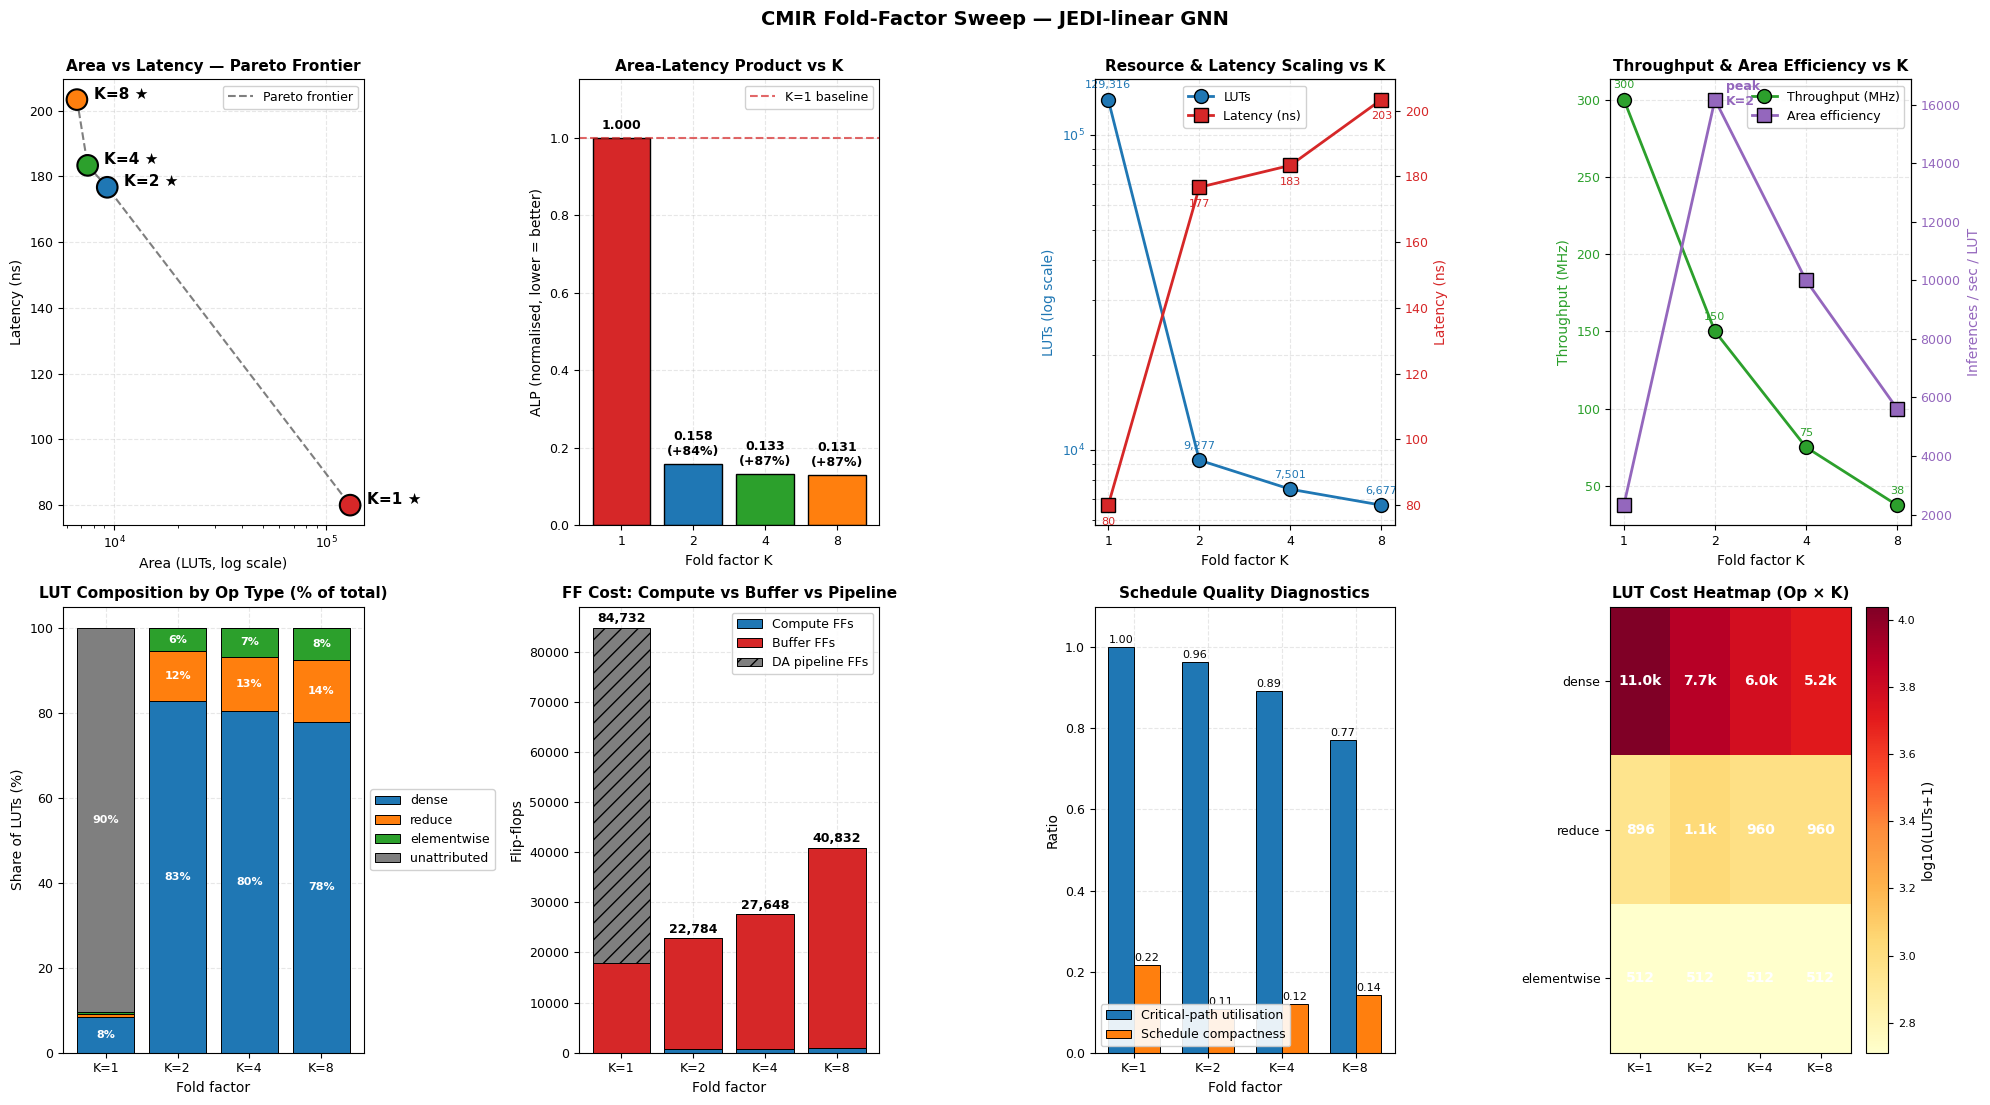

In [13]:
fig = plot.plot_dashboard(results, figsize=(20, 11))
plt.show()

## Per-op breakdown (raw)

The numbers behind the heatmap and composition charts.

In [14]:
rows = []
for K in sorted(results.keys()):
    for op, c in results[K].get('op_breakdown', {}).items():
        rows.append({
            'K': K, 'op': op,
            'count': c.get('count', 0),
            'LUTs': c.get('lut', 0),
            'FFs': c.get('ff', 0),
            'DSPs': c.get('dsp', 0),
            'BRAMs': c.get('bram', 0),
        })
pd.DataFrame(rows).pivot_table(index='op', columns='K', values=['LUTs', 'FFs'], fill_value=0)

FFs                                LUTs                  \
K                  1        2        4        8        1       2       4   
op                                                                         
buffer       17920.0  22080.0  26816.0  39872.0      0.0     0.0     0.0   
dense            0.0      0.0      0.0      0.0  10973.0  7677.0  6029.0   
elementwise      0.0      0.0      0.0      0.0    512.0   512.0   512.0   
reduce           0.0    704.0    832.0    960.0    896.0  1088.0   960.0   

                     
K                 8  
op                   
buffer          0.0  
dense        5205.0  
elementwise   512.0  
reduce        960.0